# The Partition Function, Symbolically — 1D Ising via the Transfer Matrix
### SageMath 10.9 edition

This is the CAS rewrite of `Partition_Function_01_Ising_Transfer_Matrix.ipynb`. That version computed
everything **numerically** with numpy. This one **derives** it.

| | numpy version | this version |
|---|---|---|
| eigenvalues | `3.08616`, `2.35040` | $2\cosh\beta$, $2\sinh\beta$ |
| energy per spin | a float per $\beta$ | $-\tanh\beta$, obtained by differentiating $\ln Z$ |
| $Z$ for $N=8$ | `9160.43872264256` | $256\cosh^8\!\beta + 256\sinh^8\!\beta$ |
| brute force | sum of $2^N$ floats | sum of $2^N$ **symbolic** terms, then proved equal to $\mathrm{Tr}(T^N)$ |

**Companion reading — Axler, *Linear Algebra Done Right*, §7.B, §7.C, §10.A.** Every step below is
flagged with the theorem that licenses it. The mathematics here is the mathematics you are reading
this week.

## 0. Setup

In [1]:
import itertools
print(version())

# Symbols. Declaring domain='real' lets Sage simplify hyperbolics correctly.
beta, J, h = var('beta J h', domain='real')

# GOTCHA worth knowing: never use N as a variable name in Sage --
# N() is Sage's numerical-evaluation function. We use `ns` for the number of spins.
print('N(pi, digits=12) =', N(pi, digits=12))

SageMath version 10.9, Release Date: 2026-05-04


N(pi, digits=12) = 3.14159265359


## 1. The model, and where the matrix comes from

$N$ spins $s_i=\pm1$ on a ring, $s_{N+1}\equiv s_1$:

$$E(s)=-J\sum_{i=1}^N s_i s_{i+1}-h\sum_{i=1}^N s_i,\qquad
Z=\sum_{\{s\}}e^{-\beta E(s)}$$

Split the Boltzmann weight so each **bond** contributes one factor:

$$e^{-\beta E}=\prod_{i=1}^{N}\underbrace{\exp\!\Big[\beta J s_is_{i+1}+\tfrac{\beta h}{2}(s_i+s_{i+1})\Big]}_{T(s_i,\,s_{i+1})}$$

$T$ takes two $\pm1$ arguments, so it is a $2\times2$ matrix.

In [2]:
def T_entry(s, sp):
    return exp(beta*J*s*sp + beta*h*(s + sp)/2)

T = matrix(SR, 2, 2, [[T_entry(s, sp) for sp in (1,-1)] for s in (1,-1)])
T = T.simplify_full()
show(T)
print()
print('symmetric?     ', T.is_symmetric())
print('real entries?  ', all(e.is_real() for e in T.list()))

[e^(J*beta + beta*h)         e^(-J*beta)]
[        e^(-J*beta) e^(J*beta - beta*h)]


symmetric?      True
real entries?   True


### Axler §7.29 applies

$T$ is **real and symmetric**, i.e. self-adjoint on $\mathbb{R}^2$. The **Real Spectral Theorem
(Axler 7.29)** therefore guarantees an *orthonormal* basis of eigenvectors.

That is not a convenience — it is what makes everything below legal.

In [3]:
T0 = T.subs(h == 0, J == 1)          # zero field, unit coupling
ES = T0.eigenvectors_right()
for val, vecs, mult in ES:
    print('eigenvalue :', val.simplify_full())
    print('eigenvector:', vecs[0])
v1, v2 = ES[0][1][0], ES[1][1][0]
print()
print('dot product of the two eigenvectors:', v1.dot_product(v2))
print('=> ORTHOGONAL, exactly as Axler 7.29 promises')

eigenvalue : (e^(2*beta) - 1)*e^(-beta)
eigenvector: (1, -1)
eigenvalue : (e^(2*beta) + 1)*e^(-beta)
eigenvector: (1, 1)

dot product of the two eigenvectors: 0
=> ORTHOGONAL, exactly as Axler 7.29 promises


## 2. The eigenvalues, in closed form

In [4]:
ev = [e.simplify_full() for e in T0.eigenvalues()]
lam_p = max(ev, key=lambda e: N(e.subs(beta==1)))
lam_m = min(ev, key=lambda e: N(e.subs(beta==1)))
print('lambda_+ =', lam_p)
print('lambda_- =', lam_m)
print()

# PROVE they equal 2cosh and 2sinh.
# .exponentialize() rewrites cosh/sinh as exponentials so Sage can close the identity.
def proves_zero(expr):
    return bool(expr.exponentialize().simplify_full() == 0)

print('lambda_+ == 2*cosh(beta) ?', proves_zero(lam_p - 2*cosh(beta)))
print('lambda_- == 2*sinh(beta) ?', proves_zero(lam_m - 2*sinh(beta)))

lambda_+ = (e^(2*beta) + 1)*e^(-beta)
lambda_- = (e^(2*beta) - 1)*e^(-beta)

lambda_+ == 2*cosh(beta) ? True
lambda_- == 2*sinh(beta) ? True


## 3. The week-1 exercise, done by machine

> **Prove $\operatorname{Tr}(T^N)=\lambda_+^N+\lambda_-^N$ from basis-independence of the trace.**

The argument, with Axler citations:

1. $T$ is real symmetric $\Rightarrow$ orthonormal eigenbasis exists **(7.29)**.
2. In that basis $T$ is diagonal, so $T^N$ is diagonal with entries $\lambda_\pm^N$.
3. Trace is **basis-independent** **(10.A)** — so evaluate it in the eigenbasis, not the standard one.
4. Hence $\operatorname{Tr}(T^N)=\lambda_+^N+\lambda_-^N$. $\blacksquare$

Sage can check each step.

In [5]:
# NOTE: Sage's eigenmatrix_right() returns (D, P) -- diagonal FIRST -- with A*P == P*D.
D, P = T0.eigenmatrix_right()
print('D  (eigenvalues on the diagonal):'); show(D.simplify_full())
print('P  (eigenvectors as columns):');     show(P)
print()

# Axler 7.29 in action: P's columns are orthogonal, so P diagonalises T0.
diag = (P.inverse()*T0*P).simplify_full()
print('P^-1 T P ='); show(diag)
print('is it diagonal ?', diag.is_diagonal())
print('does it equal D ?', bool((diag - D).simplify_full() == 0))
print()

# Step 2: a diagonal matrix raised to a power is diagonal with entries d_ii^n.
print('D^5 ='); show((D^5).simplify_full())
print()

# Step 3-4: trace is basis-independent (Axler 10.A), so evaluate in the eigenbasis.
for ns in (3, 5, 8):
    lhs = (T0^ns).trace().simplify_full()         # trace in the STANDARD basis
    rhs = (lam_p^ns + lam_m^ns).simplify_full()   # sum of eigenvalues^ns
    print(f'  ns={ns}:  Tr(T^ns) == lam_+^ns + lam_-^ns  ->  {proves_zero(lhs - rhs)}')

D  (eigenvalues on the diagonal):


[(e^(2*beta) - 1)*e^(-beta)                          0]
[                         0 (e^(2*beta) + 1)*e^(-beta)]

P  (eigenvectors as columns):


[ 1  1]
[-1  1]


P^-1 T P =


[(e^(2*beta) - 1)*e^(-beta)                          0]
[                         0 (e^(2*beta) + 1)*e^(-beta)]

is it diagonal ? True
does it equal D ? True

D^5 =


[(e^(10*beta) - 5*e^(8*beta) + 10*e^(6*beta) - 10*e^(4*beta) + 5*e^(2*beta) - 1)*e^(-5*beta)                                                                                           0]
[                                                                                          0 (e^(10*beta) + 5*e^(8*beta) + 10*e^(6*beta) + 10*e^(4*beta) + 5*e^(2*beta) + 1)*e^(-5*beta)]


  ns=3:  Tr(T^ns) == lam_+^ns + lam_-^ns  ->  True
  ns=5:  Tr(T^ns) == lam_+^ns + lam_-^ns  ->  True
  ns=8:  Tr(T^ns) == lam_+^ns + lam_-^ns  ->  True


## 4. Brute force: the sum over $2^N$ configurations, kept exact

The numpy notebook summed $2^N$ **floats**. Sage sums $2^N$ **symbolic terms** and returns a closed
form — so the agreement below is an *identity*, not a numerical coincidence.

In [6]:
def Z_brute(ns, Jv=1, hv=0):
    '''Exact symbolic sum over all 2^ns configurations, periodic boundary.'''
    total = 0
    for cfg in itertools.product([-1, 1], repeat=ns):
        E = -Jv*sum(cfg[i]*cfg[(i+1) % ns] for i in range(ns)) - hv*sum(cfg)
        total += exp(-beta*E)
    return total.simplify_full()

for ns in (4, 6, 8):
    print(f'ns={ns}  ({2**ns:4d} configurations):')
    print('   ', Z_brute(ns))

ns=4  (  16 configurations):
    2*(e^(8*beta) + 6*e^(4*beta) + 1)*e^(-4*beta)
ns=6  (  64 configurations):
    2*(e^(12*beta) + 15*e^(8*beta) + 15*e^(4*beta) + 1)*e^(-6*beta)
ns=8  ( 256 configurations):
    2*(e^(16*beta) + 28*e^(12*beta) + 70*e^(8*beta) + 28*e^(4*beta) + 1)*e^(-8*beta)


In [7]:
print('Transfer matrix vs brute force -- as SYMBOLIC IDENTITIES:')
for ns in (4, 6, 8, 10):
    lhs = (lam_p^ns + lam_m^ns).simplify_full()
    rhs = Z_brute(ns)
    print(f'  ns={ns:2d}  2^ns={2**ns:5d} states   identical ? {proves_zero(lhs - rhs)}')
print()
print('The numpy notebook could only show these agreed to 7.6e-13.')
print('Here they are proved equal for every beta simultaneously.')

Transfer matrix vs brute force -- as SYMBOLIC IDENTITIES:
  ns= 4  2^ns=   16 states   identical ? True
  ns= 6  2^ns=   64 states   identical ? True
  ns= 8  2^ns=  256 states   identical ? True
  ns=10  2^ns= 1024 states   identical ? True

The numpy notebook could only show these agreed to 7.6e-13.
Here they are proved equal for every beta simultaneously.


## 5. Thermodynamics by differentiation, not finite differences

In the thermodynamic limit $(\lambda_-/\lambda_+)^N\to0$, so only $\lambda_+$ survives:

$$f=-\frac{1}{\beta}\ln\lambda_+,\qquad u=\frac{\partial(\beta f)}{\partial\beta},\qquad
\frac{C}{k_B}=-\beta^2\frac{\partial u}{\partial\beta}$$

In [8]:
f = (-log(lam_p)/beta).simplify_full()
u = diff(beta*f, beta).simplify_full()
Cv = (-beta^2*diff(u, beta)).simplify_full()

print('f   =', f)
print('u   =', u)
print('C/k =', Cv)
print()
print('u == -tanh(beta) ?  ', proves_zero(u + tanh(beta)))
print('C == (beta/cosh)^2 ?', proves_zero(Cv - (beta/cosh(beta))^2))
print()
print('cross-check against the numpy notebook:')
for b in [0.2, 0.5, 1.0, 2.0, 3.0]:
    print(f'   beta={b:4.1f}   f={N(f.subs(beta==b)):+9.5f}   u={N(u.subs(beta==b)):+9.5f}   C/k={N(Cv.subs(beta==b)):8.5f}')

f   = -log((e^(2*beta) + 1)*e^(-beta))/beta
u   = -(e^(2*beta) - 1)/(e^(2*beta) + 1)
C/k = 4*beta^2*e^(2*beta)/(e^(4*beta) + 2*e^(2*beta) + 1)

u == -tanh(beta) ?   True
C == (beta/cosh)^2 ? True

cross-check against the numpy notebook:
   beta= 0.2   f= -3.56508   u= -0.19738   C/k= 0.03844
   beta= 0.5   f= -1.62652   u= -0.46212   C/k= 0.19661
   beta= 1.0   f= -1.12693   u= -0.76159   C/k= 0.41997
   beta= 2.0   f= -1.00907   u= -0.96403   C/k= 0.28260
   beta= 3.0   f= -1.00083   u= -0.99505   C/k= 0.08879


## 6. The correlation length **is** the spectral gap

$$\langle s_0s_r\rangle=\left(\frac{\lambda_-}{\lambda_+}\right)^{r}=e^{-r/\xi},
\qquad \xi=\frac{1}{\ln(\lambda_+/\lambda_-)}$$

Sage gives $\xi$ exactly, and we can take its limits.

In [9]:
xi = (1/log(lam_p/lam_m)).simplify_full()
print('xi =', xi)
print('  simplified:', (1/log(coth(beta))).simplify_full(), '  [ = 1/log(coth(beta)) ]')
print('  identity? ', proves_zero(xi - 1/log(coth(beta))))
print()
for b in [0.2, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
    print(f'   beta={b:4.1f}   lam+/lam-={N(lam_p.subs(beta==b)/lam_m.subs(beta==b)):8.4f}   xi={N(xi.subs(beta==b)):9.4f}')
print()
print('LOW temperature limit (beta -> oo):  xi ->', xi.limit(beta=oo), ' (diverges)')
print()
print('Asymptotic form. For large beta, coth(beta) = 1 + 2e^(-2beta) + ...,')
print('so log(coth beta) ~ 2e^(-2beta), giving  xi ~ (1/2)e^(2beta).')
xi_asym = exp(2*beta)/2
print()
print(f'   {"beta":>5} {"xi exact":>12} {"(1/2)e^(2beta)":>16} {"ratio":>8}')
for b in [1.0, 1.5, 2.0, 2.5, 3.0, 4.0]:
    e_, a_ = N(xi.subs(beta==b)), N(xi_asym.subs(beta==b))
    print(f'   {b:5.1f} {e_:12.4f} {a_:16.4f} {e_/a_:8.5f}')
print()
print('ratio -> 1: the asymptotic is confirmed. xi grows EXPONENTIALLY in beta.')

xi = 1/log((e^(2*beta) + 1)/(e^(2*beta) - 1))
  simplified: 1/log(cosh(beta)/sinh(beta))   [ = 1/log(coth(beta)) ]
  identity?  True

   beta= 0.2   lam+/lam-=  5.0665   xi=   0.6163
   beta= 0.5   lam+/lam-=  2.1640   xi=   1.2954
   beta= 1.0   lam+/lam-=  1.3130   xi=   3.6719
   beta= 1.5   lam+/lam-=  1.1048   xi=  10.0345
   beta= 2.0   lam+/lam-=  1.0373   xi=  27.2960
   beta= 2.5   lam+/lam-=  1.0136   xi=  74.2055
   beta= 3.0   lam+/lam-=  1.0050   xi= 201.7140

LOW temperature limit (beta -> oo):  xi -> +Infinity  (diverges)

Asymptotic form. For large beta, coth(beta) = 1 + 2e^(-2beta) + ...,
so log(coth beta) ~ 2e^(-2beta), giving  xi ~ (1/2)e^(2beta).

    beta     xi exact (Integer(1)/Integer(2))e**(2beta)    ratio
     1.0       3.6719           3.6945  0.99386
     1.5      10.0345          10.0428  0.99917
     2.0      27.2960          27.2991  0.99989
     2.5      74.2055          74.2066  0.99998
     3.0     201.7140         201.7144  1.00000
     4.0    1490.47

## 7. Why there is no phase transition in 1D — provable here

A phase transition is a **non-analyticity** of $f$. For this model $f=-\frac1\beta\ln(2\cosh\beta)$,
which is analytic for all $\beta>0$: $\cosh\beta>0$ always, so $\ln$ never hits its branch point.

That is the one-line version of a theorem. Sage can show the function is smooth.

In [10]:
print('f  =', f)
print('lam_+ = 2cosh(beta) is never zero for real beta:')
print('   solve(2*cosh(beta) == 0, beta) ->', solve(2*cosh(beta) == 0, beta))
print()
print('all derivatives exist and are finite at every beta > 0; e.g. at beta=1:')
g = f
for k in range(1, 5):
    g = diff(g, beta)
    print(f'   d^{k}f/dbeta^{k} at beta=1 = {N(g.subs(beta==1)):+.6f}')
print()
print('Contrast: a phase transition requires f to lose analyticity at some finite beta_c.')
print('In 2D (Onsager) that happens. See Feynman, Statistical Mechanics, ch.5.4.')

f  = -log((e^(2*beta) + 1)*e^(-beta))/beta
lam_+ = 2cosh(beta) is never zero for real beta:
   solve(2*cosh(beta) == 0, beta) -> [

]

all derivatives exist and are finite at every beta > 0; e.g. at beta=1:
   d^1f/dbeta^1 at beta=1 = +0.365334
   d^2f/dbeta^2 at beta=1 = -1.150642
   d^3f/dbeta^3 at beta=1 = +4.091626
   d^4f/dbeta^4 at beta=1 = -16.988131

Contrast: a phase transition requires f to lose analyticity at some finite beta_c.
In 2D (Onsager) that happens. See Feynman, Statistical Mechanics, ch.5.4.


## 8. Plots — Sage's own plotting, from the symbolic expressions

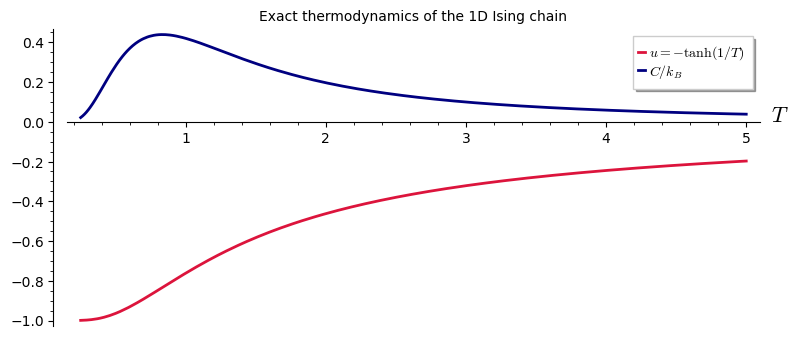

In [11]:
p1 = plot(u.subs(beta==1/x), (x, 0.25, 5), color='crimson', legend_label='$u=-\\tanh(1/T)$',
          axes_labels=['$T$', ''], thickness=2)
p2 = plot(Cv.subs(beta==1/x), (x, 0.25, 5), color='navy', legend_label='$C/k_B$', thickness=2)
show(p1 + p2, figsize=(8,3.5), title='Exact thermodynamics of the 1D Ising chain')

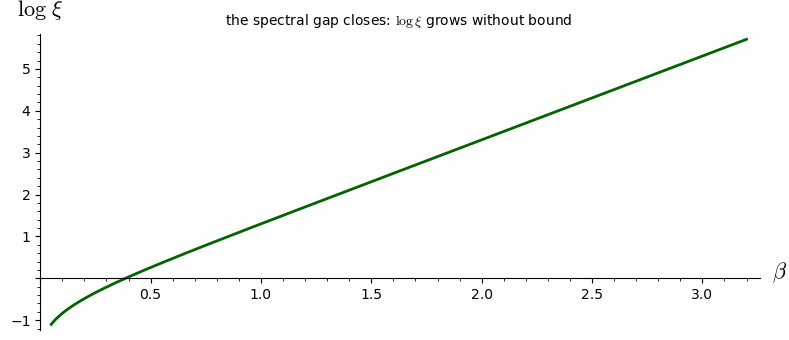

In [12]:
show(plot(log(xi), (beta, 0.05, 3.2), thickness=2, color='darkgreen',
          axes_labels=['$\\beta$', '$\\log\\,\\xi$'],
          title='the spectral gap closes: $\\log\\xi$ grows without bound'),
     figsize=(8,3.5))

## 9. Where the exact route stops — and Monte Carlo must take over

Everything above was exact because the transfer matrix is $2\times2$. **That is a feature of one
dimension only.** In 2D the transfer matrix for an $L\times L$ lattice is $2^L\times2^L$ — Onsager's
1944 solution is famous precisely because diagonalising it is hard.

So for anything harder you sample. And sampling has a failure mode the exact route does not.
The numpy companion notebook measures it; here is the *reason*, exactly.

In [13]:
print('Metropolis must cross a barrier to flip the global magnetisation.')
print('The time to do so grows like exp(beta * Delta E), while the correlation')
print('length grows as:')
for b in [1.0, 2.0, 3.0]:
    print(f'   beta={b}:  xi = {N(xi.subs(beta==b)):8.3f} lattice spacings')
print()
print('Once xi exceeds the system size N, the chain is one domain and cannot')
print('decorrelate within any feasible run. At beta=3, xi = 202 > N = 64.')
print()
print('=> see Partition_Function_01_Ising_Transfer_Matrix.ipynb section 7,')
print('   where 6 independent chains return +-1 when the exact answer is 0.')

Metropolis must cross a barrier to flip the global magnetisation.
The time to do so grows like exp(beta * Delta E), while the correlation
length grows as:
   beta=1.00000000000000:  xi =    3.672 lattice spacings
   beta=2.00000000000000:  xi =   27.296 lattice spacings
   beta=3.00000000000000:  xi =  201.714 lattice spacings

Once xi exceeds the system size N, the chain is one domain and cannot
decorrelate within any feasible run. At beta=3, xi = 202 > N = 64.

=> see Partition_Function_01_Ising_Transfer_Matrix.ipynb section 7,
   where 6 independent chains return +-1 when the exact answer is 0.


---
## 10. What to take from this

1. **$Z$ is an eigenvalue problem.** A sum over $2^N$ states collapsed to $\lambda_+^N+\lambda_-^N$ —
   licensed by Axler **7.29** (orthonormal eigenbasis) and **10.A** (basis-independent trace).
2. **Exact beats approximate where it is available.** $u=-\tanh\beta$ was *derived*, not fitted.
3. **The spectral gap is the physics.** $\xi=1/\ln\coth\beta$ — one eigenvalue ratio controls how far
   correlations reach, and therefore when sampling fails.
4. **This is the transfer *operator* of Part IX in miniature.** Leading eigenvalue $\to$ free energy;
   gap $\to$ relaxation. In molecular systems the matrix becomes an operator on conformation space,
   but the structure is identical.

### Exercises

1. Put $h\neq0$ back. Show $\lambda_\pm=e^{\beta J}\cosh\beta h\pm\sqrt{e^{2\beta J}\sinh^2\!\beta h+e^{-2\beta J}}$ and derive $m(h)=\partial f/\partial h$.
2. Antiferromagnet: set $J=-1$. What happens to $\lambda_\pm$, and to $\xi$?
3. Time `Z_brute` for `ns = 4,6,8,10,12`. Fit the growth; extrapolate to `ns = 30`.
4. Prove step 2 of §3 properly on paper: if $D$ is diagonal then $D^n$ is diagonal with entries $d_{ii}^n$.
5. Build the transfer matrix for a $2\times L$ ladder. What size is it? Now $L\times L$.